<a href="https://colab.research.google.com/github/dystaSatria/Deep-Learning/blob/main/Internship%20Projects/catboost/catboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


✅ CatBoost berhasil diimport!
=== CONTOH CATBOOST SEDERHANA ===

1. Membuat dataset dengan categorical features...
Dataset shape: (1000, 8)

Contoh data:
   age        income  experience      city education    job_type  \
0   56  25903.305196           4  Semarang       SMA  Wiraswasta   
1   69  53051.954538          25  Semarang        S3        BUMN   
2   46  38654.738821           3   Jakarta   Diploma        BUMN   
3   32  28666.194356          14   Jakarta        S3      Swasta   
4   60  40301.406736          28  Semarang        S2  Wiraswasta   

   loan_approved  predicted_salary  
0              0      33550.671881  
1              1      67867.394941  
2              0      40862.011243  
3              1      64570.525879  
4              1      73975.195903  

Distribusi target classification (loan_approved):
loan_approved
1    918
0     82
Name: count, dtype: int64

Categorical features: ['city', 'education', 'job_type']

2. Classification dengan CatBoost...
Training Ca

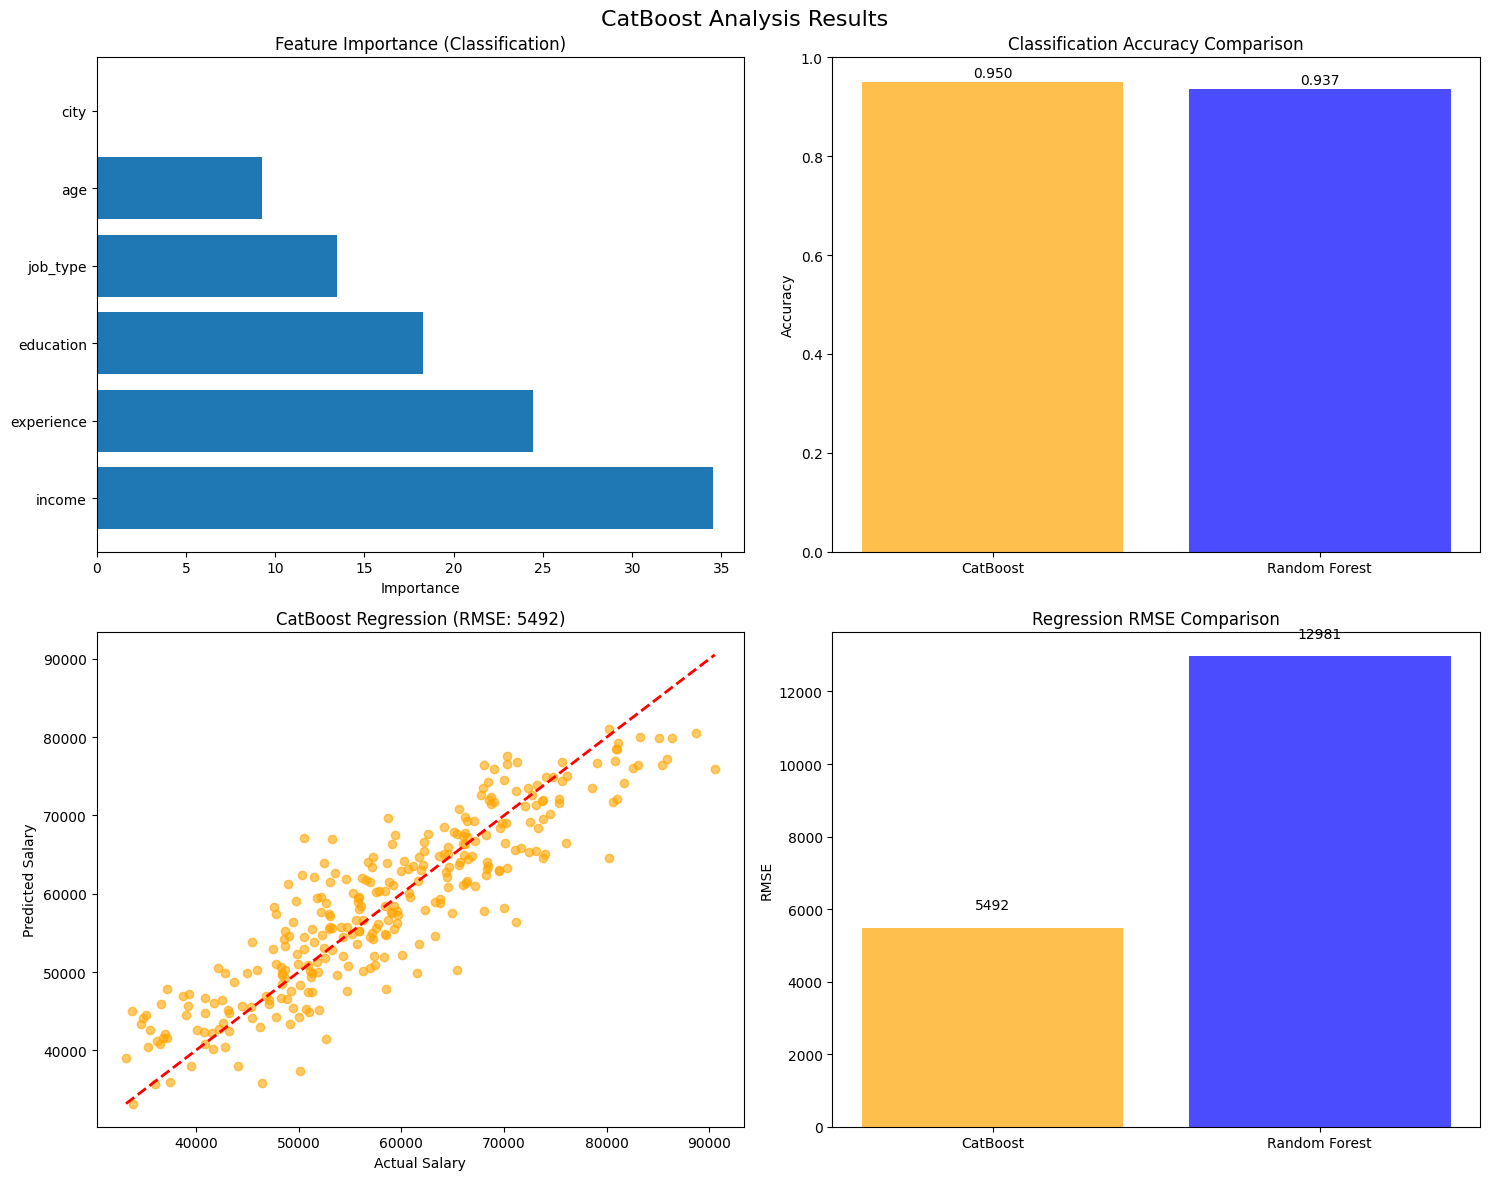


7. Categorical Feature Analysis...

CITY Analysis:
              mean  count
city                     
Bandung   0.917476    206
Jakarta   0.925234    214
Medan     0.943299    194
Semarang  0.905473    201
Surabaya  0.897297    185

EDUCATION Analysis:
               mean  count
education                 
Diploma    0.894472    199
S1         0.898058    206
S2         0.974747    198
S3         0.990610    213
SMA        0.820652    184

JOB_TYPE Analysis:
                mean  count
job_type                   
BUMN        0.919355    248
PNS         0.971774    248
Swasta      0.906504    246
Wiraswasta  0.875969    258

8. Model Evaluation Detail...

Classification Report (CatBoost):
              precision    recall  f1-score   support

           0       0.92      0.44      0.59        25
           1       0.95      1.00      0.97       275

    accuracy                           0.95       300
   macro avg       0.93      0.72      0.78       300
weighted avg       0.95      0

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Import CatBoost
try:
    from catboost import CatBoostClassifier, CatBoostRegressor, Pool
    print("✅ CatBoost berhasil diimport!")
except ImportError:
    print("❌ CatBoost belum terinstall. Install dengan: pip install catboost")
    exit()

print("=== CONTOH CATBOOST SEDERHANA ===\n")

# 1. MEMBUAT DATASET DENGAN CATEGORICAL FEATURES
print("1. Membuat dataset dengan categorical features...")

# Membuat dataset buatan
np.random.seed(42)
n_samples = 1000

# Numerical features
numerical_data = {
    'age': np.random.randint(18, 70, n_samples),
    'income': np.random.normal(50000, 15000, n_samples),
    'experience': np.random.randint(0, 30, n_samples)
}

# Categorical features
cities = ['Jakarta', 'Surabaya', 'Bandung', 'Medan', 'Semarang']
education = ['SMA', 'Diploma', 'S1', 'S2', 'S3']
job_type = ['Swasta', 'PNS', 'Wiraswasta', 'BUMN']

categorical_data = {
    'city': np.random.choice(cities, n_samples),
    'education': np.random.choice(education, n_samples),
    'job_type': np.random.choice(job_type, n_samples)
}

# Membuat target berdasarkan logika bisnis
# Target classification: approval loan (0 atau 1)
df = pd.DataFrame({**numerical_data, **categorical_data})

# Logika untuk target classification
def create_loan_approval(row):
    score = 0
    score += (row['income'] - 30000) / 10000  # Income factor
    score += row['experience'] / 10  # Experience factor
    score += {'S3': 3, 'S2': 2, 'S1': 1, 'Diploma': 0.5, 'SMA': 0}[row['education']]
    score += {'PNS': 2, 'BUMN': 1.5, 'Swasta': 1, 'Wiraswasta': 0.5}[row['job_type']]

    # Add some noise
    score += np.random.normal(0, 1)

    return 1 if score > 3 else 0

df['loan_approved'] = df.apply(create_loan_approval, axis=1)

# Target regression: predicted salary
def create_salary_target(row):
    salary = 30000  # Base salary
    salary += row['experience'] * 1000  # Experience bonus
    salary += {'S3': 15000, 'S2': 10000, 'S1': 5000, 'Diploma': 2000, 'SMA': 0}[row['education']]
    salary += {'PNS': 8000, 'BUMN': 6000, 'Swasta': 3000, 'Wiraswasta': 1000}[row['job_type']]
    salary += {'Jakarta': 5000, 'Surabaya': 3000, 'Bandung': 2000, 'Medan': 1000, 'Semarang': 500}[row['city']]

    # Add noise
    salary += np.random.normal(0, 5000)
    return max(salary, 20000)  # Minimum salary

df['predicted_salary'] = df.apply(create_salary_target, axis=1)

print(f"Dataset shape: {df.shape}")
print("\nContoh data:")
print(df.head())

print(f"\nDistribusi target classification (loan_approved):")
print(df['loan_approved'].value_counts())

# Identifikasi categorical columns
categorical_features = ['city', 'education', 'job_type']
print(f"\nCategorical features: {categorical_features}")

# 2. CLASSIFICATION DENGAN CATBOOST
print("\n2. Classification dengan CatBoost...")

# Prepare data for classification
X = df.drop(['loan_approved', 'predicted_salary'], axis=1)
y_class = df['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.3, random_state=42, stratify=y_class
)

# CatBoost Classifier - Sangat mudah digunakan!
catboost_clf = CatBoostClassifier(
    iterations=100,              # Jumlah trees
    learning_rate=0.1,           # Learning rate
    depth=6,                     # Tree depth
    cat_features=categorical_features,  # Specify categorical features
    verbose=False,               # Suppress output
    random_seed=42
)

# Training - CatBoost secara otomatis menangani categorical features!
print("Training CatBoost Classifier...")
catboost_clf.fit(X_train, y_train)

# Prediction
y_pred_cat = catboost_clf.predict(X_test)
accuracy_cat = accuracy_score(y_test, y_pred_cat)

print(f"CatBoost Classification Accuracy: {accuracy_cat:.4f}")

# 3. PERBANDINGAN DENGAN RANDOM FOREST
print("\n3. Perbandingan dengan Random Forest...")

# Untuk Random Forest, kita perlu encode categorical features
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train[col])
    X_test_encoded[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_encoded, y_train)
y_pred_rf = rf_clf.predict(X_test_encoded)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Classification Accuracy: {accuracy_rf:.4f}")
print(f"CatBoost vs Random Forest: {accuracy_cat - accuracy_rf:+.4f}")

# 4. REGRESSION DENGAN CATBOOST
print("\n4. Regression dengan CatBoost...")

# Prepare data for regression
y_reg = df['predicted_salary']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=42
)

# CatBoost Regressor
catboost_reg = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    cat_features=categorical_features,
    verbose=False,
    random_seed=42
)

print("Training CatBoost Regressor...")
catboost_reg.fit(X_train_reg, y_train_reg)

# Prediction
y_pred_reg_cat = catboost_reg.predict(X_test_reg)
rmse_cat = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_cat))

print(f"CatBoost Regression RMSE: {rmse_cat:.2f}")

# Random Forest Regression for comparison
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_encoded, y_train_reg)
y_pred_reg_rf = rf_reg.predict(X_test_encoded)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_rf))

print(f"Random Forest Regression RMSE: {rmse_rf:.2f}")
print(f"CatBoost vs Random Forest RMSE: {rmse_cat - rmse_rf:+.2f}")

# 5. FEATURE IMPORTANCE
print("\n5. Feature Importance Analysis...")

# Classification feature importance
feature_importance_clf = catboost_clf.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_clf
}).sort_values('importance', ascending=False)

print("Top 5 Feature Importance (Classification):")
print(importance_df.head())

# 6. VISUALISASI
print("\n6. Membuat visualisasi...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('CatBoost Analysis Results', fontsize=16)

# Plot 1: Feature Importance Classification
axes[0,0].barh(importance_df['feature'], importance_df['importance'])
axes[0,0].set_title('Feature Importance (Classification)')
axes[0,0].set_xlabel('Importance')

# Plot 2: Classification Results Comparison
models = ['CatBoost', 'Random Forest']
accuracies = [accuracy_cat, accuracy_rf]
axes[0,1].bar(models, accuracies, color=['orange', 'blue'], alpha=0.7)
axes[0,1].set_title('Classification Accuracy Comparison')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_ylim(0, 1)
for i, acc in enumerate(accuracies):
    axes[0,1].text(i, acc + 0.01, f'{acc:.3f}', ha='center')

# Plot 3: Regression Predictions vs Actual
axes[1,0].scatter(y_test_reg, y_pred_reg_cat, alpha=0.6, color='orange')
axes[1,0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1,0].set_xlabel('Actual Salary')
axes[1,0].set_ylabel('Predicted Salary')
axes[1,0].set_title(f'CatBoost Regression (RMSE: {rmse_cat:.0f})')

# Plot 4: RMSE Comparison
rmse_values = [rmse_cat, rmse_rf]
axes[1,1].bar(models, rmse_values, color=['orange', 'blue'], alpha=0.7)
axes[1,1].set_title('Regression RMSE Comparison')
axes[1,1].set_ylabel('RMSE')
for i, rmse in enumerate(rmse_values):
    axes[1,1].text(i, rmse + 500, f'{rmse:.0f}', ha='center')

plt.tight_layout()
plt.show()

# 7. CATEGORICAL FEATURE ANALYSIS
print("\n7. Categorical Feature Analysis...")

# Lihat bagaimana CatBoost menangani categorical features
for cat_feature in categorical_features:
    print(f"\n{cat_feature.upper()} Analysis:")
    approval_by_category = df.groupby(cat_feature)['loan_approved'].agg(['mean', 'count'])
    print(approval_by_category)

# 8. MODEL EVALUATION DETAIL
print("\n8. Model Evaluation Detail...")

print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_pred_cat))

# Prediction probability
y_proba = catboost_clf.predict_proba(X_test)[:, 1]
print(f"\nPrediction Probability Stats:")
print(f"Mean probability: {np.mean(y_proba):.3f}")
print(f"Std probability: {np.std(y_proba):.3f}")

# 9. CONTOH PREDIKSI UNTUK DATA BARU
print("\n9. Contoh Prediksi untuk Data Baru...")

# Membuat contoh data baru
new_data = pd.DataFrame({
    'age': [35, 45, 25],
    'income': [60000, 80000, 35000],
    'experience': [10, 15, 2],
    'city': ['Jakarta', 'Surabaya', 'Bandung'],
    'education': ['S1', 'S2', 'SMA'],
    'job_type': ['Swasta', 'PNS', 'Wiraswasta']
})

print("Data baru untuk prediksi:")
print(new_data)

# Prediksi loan approval
loan_predictions = catboost_clf.predict(new_data)
loan_probabilities = catboost_clf.predict_proba(new_data)[:, 1]

# Prediksi salary
salary_predictions = catboost_reg.predict(new_data)

print("\nHasil Prediksi:")
for i in range(len(new_data)):
    print(f"Person {i+1}:")
    print(f"  Loan Approved: {'Yes' if loan_predictions[i] == 1 else 'No'} (Prob: {loan_probabilities[i]:.3f})")
    print(f"  Predicted Salary: Rp {salary_predictions[i]:,.0f}")
    print()

# 10. KEUNGGULAN CATBOOST
print("10. Keunggulan CatBoost:")
print("""
✅ KEUNGGULAN CATBOOST:
1. Otomatis menangani categorical features tanpa preprocessing
2. Memiliki built-in overfitting protection
3. Performa tinggi out-of-the-box dengan minimal tuning
4. Mendukung missing values secara otomatis
5. Fast inference dan training
6. Built-in feature importance
7. Tidak memerlukan extensive hyperparameter tuning

🎯 KAPAN MENGGUNAKAN CATBOOST:
- Dataset dengan banyak categorical features
- Butuh model yang cepat dan akurat
- Minimal preprocessing time
- Competitive machine learning

⚠️ PERTIMBANGAN:
- Memory usage cukup tinggi untuk dataset besar
- Training time bisa lebih lama dibanding LightGBM untuk dataset sangat besar
""")

print("\n=== SELESAI ===")

# Tips untuk optimasi lebih lanjut
print("\n💡 TIPS OPTIMASI:")
print("""
# Untuk dataset besar:
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    cat_features=categorical_features,
    eval_metric='AUC',
    verbose=100
)

# Untuk early stopping:
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=False
)
""")